In [1]:
import tensorflow as tf
tf.test.is_built_with_cuda()
tf.test.is_gpu_available(cuda_only=False, min_cuda_compute_capability=None)

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


True

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# prompt: i have "/content/kaggle.json" now I have to download data dogs vs cats from kaggle

import os
os.environ['KAGGLE_CONFIG_DIR'] = "/content"

!kaggle datasets download -d biaiscience/dogs-vs-cats

!unzip dogs-vs-cats.zip -d /content/dogs-vs-cats

Streaming output truncated to the last 5000 lines.
  inflating: /content/dogs-vs-cats/train/train/dog.5499.jpg  
  inflating: /content/dogs-vs-cats/train/train/dog.55.jpg  
  inflating: /content/dogs-vs-cats/train/train/dog.550.jpg  
  inflating: /content/dogs-vs-cats/train/train/dog.5500.jpg  
  inflating: /content/dogs-vs-cats/train/train/dog.5501.jpg  
  inflating: /content/dogs-vs-cats/train/train/dog.5502.jpg  
  inflating: /content/dogs-vs-cats/train/train/dog.5503.jpg  
  inflating: /content/dogs-vs-cats/train/train/dog.5504.jpg  
  inflating: /content/dogs-vs-cats/train/train/dog.5505.jpg  
  inflating: /content/dogs-vs-cats/train/train/dog.5506.jpg  
  inflating: /content/dogs-vs-cats/train/train/dog.5507.jpg  
  inflating: /content/dogs-vs-cats/train/train/dog.5508.jpg  
  inflating: /content/dogs-vs-cats/train/train/dog.5509.jpg  
  inflating: /content/dogs-vs-cats/train/train/dog.551.jpg  
  inflating: /content/dogs-vs-cats/train/train/dog.5510.jpg  
  inflating: /content/d

In [5]:
import os, shutil
original_dataset_dir = '/content/dogs-vs-cats/train/train'
base_dir = '/content/dog_cat1/abc/'
os.mkdir(base_dir)
train_dir = os.path.join(base_dir, 'train')
os.mkdir(train_dir)
validation_dir = os.path.join(base_dir, 'validation')
os.mkdir(validation_dir)
test_dir = os.path.join(base_dir, 'test')
os.mkdir(test_dir)
train_cats_dir = os.path.join(train_dir, 'cats')
os.mkdir(train_cats_dir)
train_dogs_dir = os.path.join(train_dir, 'dogs')
os.mkdir(train_dogs_dir)
validation_cats_dir = os.path.join(validation_dir, 'cats')
os.mkdir(validation_cats_dir)
validation_dogs_dir = os.path.join(validation_dir, 'dogs')
os.mkdir(validation_dogs_dir)
test_cats_dir = os.path.join(test_dir, 'cats')
os.mkdir(test_cats_dir)
test_dogs_dir = os.path.join(test_dir, 'dogs')
os.mkdir(test_dogs_dir)
fnames = ['cat.{}.jpg'.format(i) for i in range(1000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(train_cats_dir, fname)
    shutil.copyfile(src, dst)
fnames = ['cat.{}.jpg'.format(i) for i in range(1000, 1500)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(validation_cats_dir, fname)
    shutil.copyfile(src, dst)
fnames = ['cat.{}.jpg'.format(i) for i in range(1500, 2000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(test_cats_dir, fname)
    shutil.copyfile(src, dst)

fnames = ['dog.{}.jpg'.format(i) for i in range(1000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(train_dogs_dir, fname)
    shutil.copyfile(src, dst)
fnames = ['dog.{}.jpg'.format(i) for i in range(1000, 1500)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(validation_dogs_dir, fname)
    shutil.copyfile(src, dst)
    fnames = ['dog.{}.jpg'.format(i) for i in range(1500, 2000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(test_dogs_dir, fname)
    shutil.copyfile(src, dst)

In [6]:
print('total training cat images:', len(os.listdir(train_cats_dir)))

print('total training dog images:', len(os.listdir(train_dogs_dir)))

print('total validation cat images:', len(os.listdir(validation_cats_dir)))

print('total validation dog images:', len(os.listdir(validation_dogs_dir)))

print('total test cat images:', len(os.listdir(test_cats_dir)))

print('total test dog images:', len(os.listdir(test_dogs_dir)))


total training cat images: 1000
total training dog images: 1000
total validation cat images: 500
total validation dog images: 500
total test cat images: 500
total test dog images: 500


# Listing 5.5 Instantiating a small convnet for dogs vs. cats classification

In [7]:
from tensorflow.keras import layers
from tensorflow.keras import models
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 15, 15, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       3,211,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

## Listing 5.6 Configuring the model for training

In [9]:
from tensorflow.keras import optimizers
model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate =1e-4),
              metrics=['acc'])

# Listing 5.7 Using ImageDataGenerator to read images from directories

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='binary')

validation_generator = test_datagen.flow_from_directory(validation_dir,
                                                        target_size=(150, 150),
                                                        batch_size=20,
                                                        class_mode='binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


## Listing 5.8 Fitting the model using a batch generator

In [11]:
history = model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=50)

Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - acc: 0.5164 - loss: 0.6955 - val_acc: 0.5350 - val_loss: 0.6874
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 166us/step - acc: 0.0000e+00 - loss: 0.0000e+00
Epoch 3/30


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - acc: 0.5539 - loss: 0.6816 - val_acc: 0.5980 - val_loss: 0.6611
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 103us/step - acc: 0.0000e+00 - loss: 0.0000e+00
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - acc: 0.6207 - loss: 0.6490 - val_acc: 0.5790 - val_loss: 0.6604
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 98us/step - acc: 0.0000e+00 - loss: 0.0000e+00
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - acc: 0.6456 - loss: 0.6347 - val_acc: 0.6330 - val_loss: 0.6243
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 95us/step - acc: 0.0000e+00 - loss: 0.0000e+00
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - acc: 0.7106 - loss: 0.5714 - val_acc: 0.6350 - val_loss: 0.6466
Epoch 10/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 116us/step - acc: 0.0000e+00 - loss: 0.0000e+00
Epoch 11/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - acc: 0.7209 - loss: 0.5591 - val_acc: 0.6250 - val_loss: 0.6484
Epoch 12/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 98us/ste

In [12]:
print(len(history.history['acc']))
print(len(history.history['val_acc']))
print(len(history.history['loss']))
print(len(history.history['val_loss']))

30
15
30
15


# Listing 5.9 Saving the model

In [13]:
model.save('cats_and_dogs_small.keras')

# Listing 5.10 Displaying curves of loss and accuracy during training

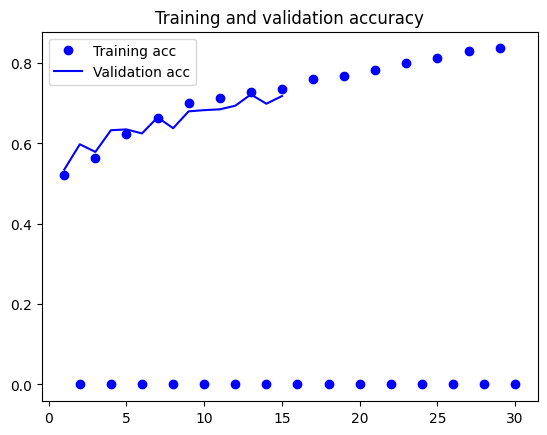

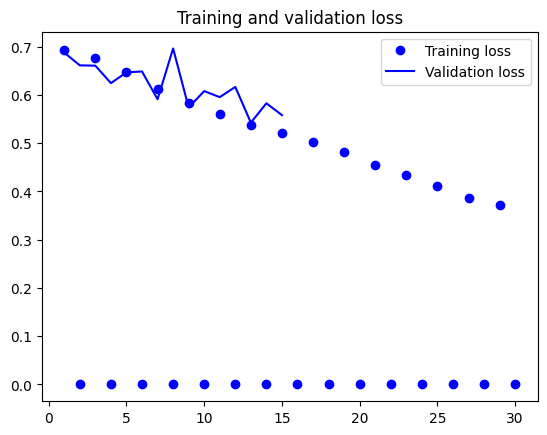

In [14]:
import matplotlib.pyplot as plt
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(range(1,16), val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(range(1,16), val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [15]:
epochs = range(1, len(acc) + 1)
epochs

range(1, 31)

# Listing 5.11 Setting up a data augmentation configuration via ImageDataGenerator

In [17]:
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

## Listing 5.12 Displaying some randomly augmented training images

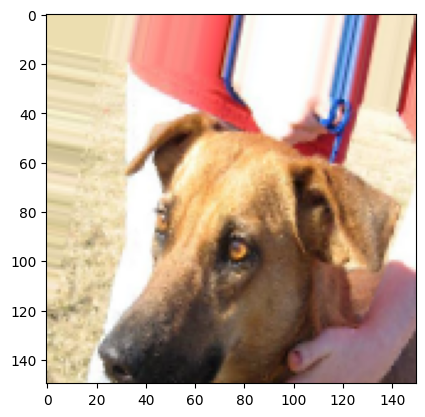

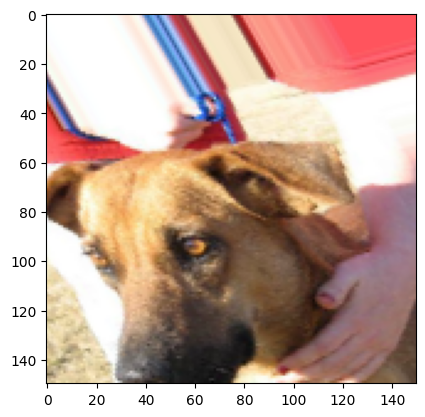

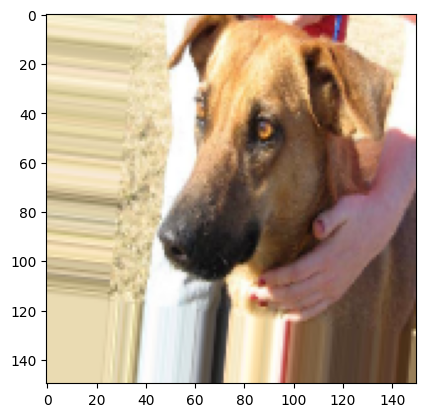

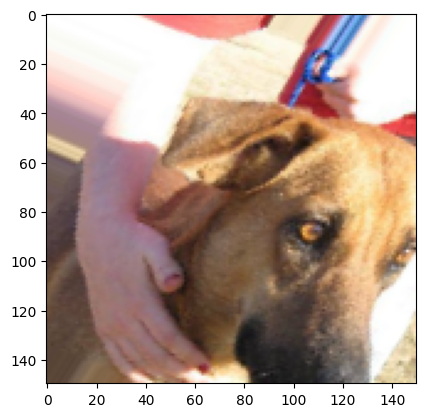

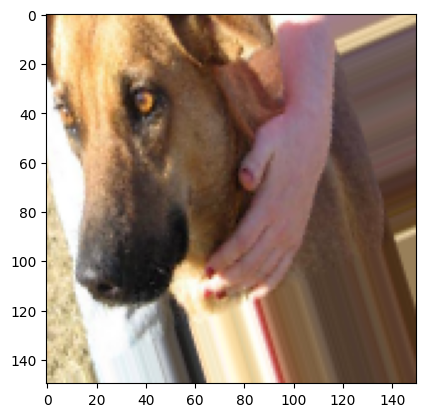

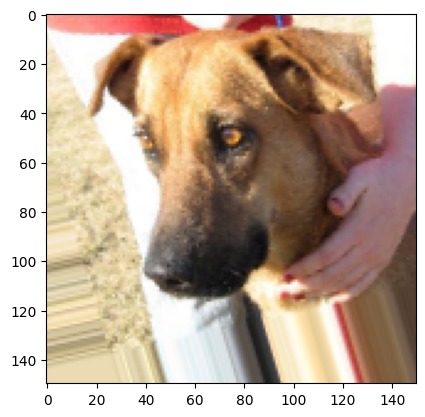

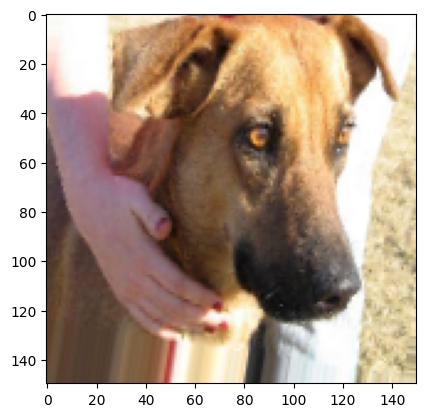

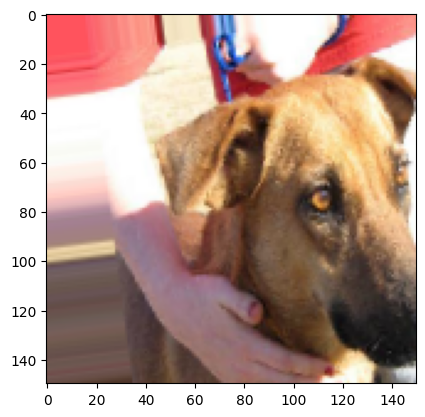

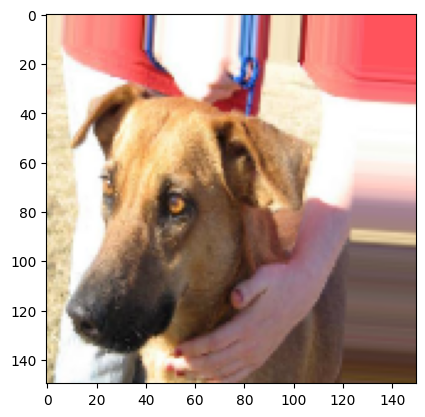

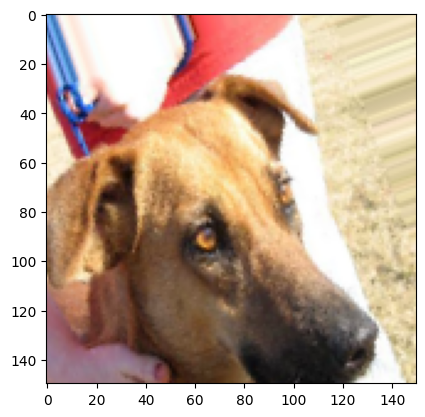

In [27]:
from tensorflow.keras.preprocessing import image
fnames = [os.path.join(train_dogs_dir, fname) for
          fname in os.listdir(train_dogs_dir)]
img_path = fnames[12]
img = image.load_img(img_path, target_size=(150, 150))


x = image.img_to_array(img)
x = x.reshape((1,) + x.shape)
i=0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(image.array_to_img(batch[0]))
    i += 1
    if i % 10 == 0:
        break
plt.show()

## Listing 5.13 Defining a new convnet that includes dropout

In [20]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-4),
              metrics=['acc'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Listing 5.14 Training the convnet using data-augmentation generators

In [22]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary')
validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary')
history = model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=100,
    validation_data=validation_generator,
    validation_steps=50)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 63/100 ━━━━━━━━━━━━━━━━━━━━ 7s 201ms/step - acc: 0.5030 - loss: 0.6969

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 158ms/step - acc: 0.5039 - loss: 0.6959 - val_acc: 0.4990 - val_loss: 0.6960
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - acc: 0.5157 - loss: 0.6932 - val_acc: 0.5330 - val_loss: 0.6874
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 114ms/step - acc: 0.5447 - loss: 0.6894 - val_acc: 0.5300 - val_loss: 0.6854
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - acc: 0.5459 - loss: 0.6858 - val_acc: 0.5860 - val_loss: 0.6768
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 114ms/step - acc: 0.5604 - loss: 0.6793 - val_acc: 0.5390 - val_loss: 0.6784
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - acc: 0.5924 - loss: 0.6725 - val_acc: 0.5940 - val_loss: 0.6627
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - acc: 0.5761 - loss: 0.6721 - val_acc: 0.5930 - val_loss: 0.6601
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - acc: 0.6040 - loss: 0.6605 - val_acc: 0.5820 - val_loss: 0.6696
Epoch 9/100
100/100 ━━━━━━━━━━━━━━━━

KeyboardInterrupt: 

## Listing 5.15 Saving the model

In [ ]:
model.save('cats_and_dogs_small_2.h5')